# A4 - st126161 - Task 2 Sentence BERT

!pip install torch datasets tqdm


## 2. Import libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)


/Users/michaellacar/Documents/AIT Documents/25-2/NLP/Code_along/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/michaellacar/Documents/AIT Documents/25-2/NLP/Code_along/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using: mps


## 3. Load SNLI Dataset

In [2]:
dataset = load_dataset("snli")

train_data = dataset["train"]

print(train_data[0])


Generating train split: 100%|██████████| 550152/550152 [00:00<00:00, 3862676.05 examples/s]


{'premise': 'A person on a horse jumps over a broken down airplane.', 'hypothesis': 'A person is training his horse for a competition.', 'label': 1}


## 4. Load Trained BERT (task 1)

In [4]:
# Load full checkpoint from Task 1
checkpoint = torch.load("bert_mlm_checkpoint.pt", map_location=device)

vocab = checkpoint["vocab"]
vocab_size = checkpoint["vocab_size"]
embed_size = checkpoint["embed_size"]
layers = checkpoint["layers"]
heads = checkpoint["heads"]
max_len = checkpoint["max_len"]

print("Loaded vocab size:", vocab_size)


Loaded vocab size: 20005


### BERT Embedding

In [6]:
class BERTEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_size, max_len):
        super().__init__()
        self.token = nn.Embedding(vocab_size, embed_size)
        self.position = nn.Embedding(max_len, embed_size)
        self.segment = nn.Embedding(2, embed_size)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        segment_ids = torch.zeros_like(x)

        return self.token(x) + self.position(positions) + self.segment(segment_ids)


### TransformerBlock

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_size, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, embed_size*4),
            nn.GELU(),
            nn.Linear(embed_size*4, embed_size)
        )

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_output)
        forward = self.feed_forward(x)
        return self.norm2(x + forward)


### BERT Model

In [8]:
class BERT(nn.Module):
    def __init__(self, vocab_size, embed_size=128, layers=2, heads=4):
        super().__init__()
        self.embedding = BERTEmbedding(vocab_size, embed_size, max_len)
        self.layers = nn.ModuleList(
            [TransformerBlock(embed_size, heads) for _ in range(layers)]
        )

    def forward(self, x):
        x = self.embedding(x)
        for layer in self.layers:
            x = layer(x)
        return x


In [11]:
bert = BERT(
    vocab_size=vocab_size,
    embed_size=embed_size,
    layers=layers,
    heads=heads
).to(device)

# Remove MLM head weights before loading
state_dict = checkpoint["model_state_dict"]

# Filter out mlm_head keys
filtered_state_dict = {
    k: v for k, v in state_dict.items() 
    if not k.startswith("mlm_head")
}

bert.load_state_dict(filtered_state_dict, strict=False)

bert.eval()
print("BERT encoder loaded successfully (MLM head ignored).")


BERT encoder loaded successfully (MLM head ignored).


## Sentence Pooling

In [12]:
def mean_pooling(token_embeddings):
    return token_embeddings.mean(dim=1)


## Siamese SBERT model

In [13]:
class SentenceBERT(nn.Module):
    def __init__(self, bert_model, embedding_dim, num_classes=3):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Linear(embedding_dim * 3, num_classes)

    def forward(self, sent1, sent2):
        emb1 = mean_pooling(self.bert.embedding(sent1))
        emb2 = mean_pooling(self.bert.embedding(sent2))

        diff = torch.abs(emb1 - emb2)
        combined = torch.cat([emb1, emb2, diff], dim=1)

        logits = self.classifier(combined)
        return logits, emb1, emb2


## Tokenizer function

In [19]:
def tokenize(text):
    return text.lower().split()


## SNLI dataset

In [20]:
class SNLIDataset(Dataset):
    def __init__(self, dataset, vocab, max_len=64):
        self.data = [d for d in dataset if d["label"] != -1]
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = tokenize(text)[:self.max_len-2]
        tokens = ["[CLS]"] + tokens + ["[SEP]"]
        ids = [self.vocab.get(t, self.vocab["[UNK]"]) for t in tokens]
        padding = [self.vocab["[PAD]"]] * (self.max_len - len(ids))
        return ids + padding

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        s1 = torch.tensor(self.encode(item["premise"]), dtype=torch.long)
        s2 = torch.tensor(self.encode(item["hypothesis"]), dtype=torch.long)
        label = torch.tensor(item["label"], dtype=torch.long)

        return s1, s2, label


## Dataloader

In [21]:
# Convert HF dataset to list of dictionaries
train_samples = [
    train_data[i] 
    for i in range(20000) 
    if train_data[i]["label"] != -1
]

snli_dataset = SNLIDataset(train_samples, vocab)

loader = DataLoader(
    snli_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0  # important for Mac
)


## Initialize SBERT

In [22]:
sbert = SentenceBERT(
    bert_model=bert,
    embedding_dim=128,
    num_classes=3
).to(device)

optimizer = optim.AdamW(sbert.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()


## Training Loop (SoftMaxLoss)

In [32]:
epochs = 3
epoch_losses = []

for epoch in range(epochs):
    sbert.train()
    total_loss = 0
    correct = 0
    total = 0

    for s1, s2, labels in tqdm(loader):
        s1, s2, labels = s1.to(device), s2.to(device), labels.to(device)

        optimizer.zero_grad()

        logits, emb1, emb2 = sbert(s1, s2)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")


100%|██████████| 625/625 [00:08<00:00, 73.88it/s]


Epoch 1 | Loss: 1.0916 | Accuracy: 0.3893


100%|██████████| 625/625 [00:09<00:00, 67.36it/s]


Epoch 2 | Loss: 1.0907 | Accuracy: 0.3985


100%|██████████| 625/625 [00:08<00:00, 77.67it/s]

Epoch 3 | Loss: 1.0895 | Accuracy: 0.4028


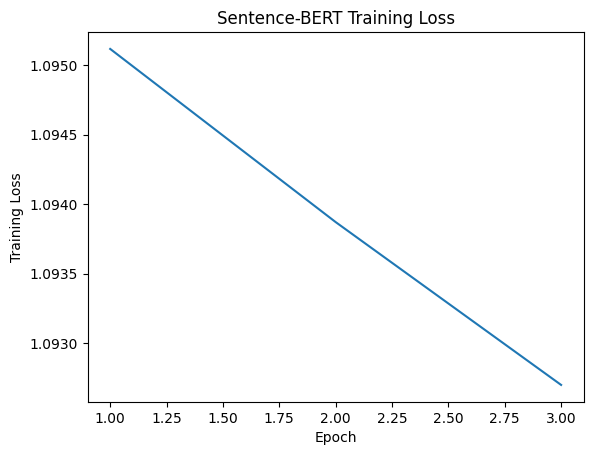

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, epochs+1), epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Sentence-BERT Training Loss")
plt.show()


## Save SBERT Model

In [34]:
torch.save(sbert.state_dict(), "sbert_snli_softmax.pt")
print("Sentence-BERT model saved.")


Sentence-BERT model saved.


## Cosine Similarity Inference

In [24]:
sbert.eval()

with torch.no_grad():
    s1, s2, _ = next(iter(loader))
    s1, s2 = s1.to(device), s2.to(device)

    _, emb1, emb2 = sbert(s1, s2)

    similarity = F.cosine_similarity(emb1, emb2)

print(similarity[:10])


tensor([0.9991, 0.9986, 0.9976, 0.9982, 0.9949, 0.9997, 0.9987, 0.9983, 0.9844,
        0.9982], device='mps:0')


Sentence-BERT was implemented using a siamese network structure with shared BERT encoders. Sentence embeddings were obtained using mean pooling. The classification objective function followed the SoftmaxLoss formulation described in Reimers & Gurevych (2019). Cosine similarity was used during inference.

# Task 3 Evaluation and Analysis

### Prepare Validation Dataset

In [29]:
# Load validation split
val_data = dataset["validation"]

val_samples = [
    val_data[i] 
    for i in range(len(val_data)) 
    if val_data[i]["label"] != -1
]

val_dataset = SNLIDataset(val_samples[:10000], vocab)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


### Generate Classification Report

In [30]:
from sklearn.metrics import classification_report

sbert.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for s1, s2, labels in val_loader:
        s1, s2 = s1.to(device), s2.to(device)

        logits, _, _ = sbert(s1, s2)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=["entailment", "neutral", "contradiction"]
))


               precision    recall  f1-score   support

   entailment       0.41      0.66      0.51      3329
      neutral       0.43      0.31      0.36      3235
contradiction       0.37      0.24      0.29      3278

     accuracy                           0.41      9842
    macro avg       0.40      0.40      0.39      9842
 weighted avg       0.40      0.41      0.39      9842

